# Two-Sample Hypothesis Testing
## Music Streaming Pipeline — Notebook 3 of 3

In this notebook I move from correlation analysis into hypothesis testing. Where Notebook 2 measured the strength of linear relationships between variables, here I am asking a different question: do specific groups of songs actually differ from each other in a statistically meaningful way? For example, are explicit songs genuinely more popular than clean songs, or does that difference just reflect random noise in the data?

To answer these questions I merged songs, albums, and audio features into a single dataset and filtered it down to the four columns needed for this investigation. Before running any tests I checked whether the data was normally distributed using histograms and the Shapiro-Wilk test. Both groups showed heavily right-skewed distributions and failed normality, so I used the Mann-Whitney U test as the non-parametric alternative rather than a standard t-test. Alongside each test I computed Cohen's d to measure the practical effect size, which is especially important here because with over 50,000 rows even a trivially small difference can produce a statistically significant p-value.

The four tests conducted in this notebook are:

| Test | Groups | Outcome |
|------|--------|---------|
| 1 | Explicit vs Clean Songs | Song Popularity |
| 2 | Singles vs Album Tracks | Song Popularity |
| 3 | High Energy vs Low Energy Songs | Song Popularity |
| 4 | Artists On Tour vs Off Tour | Artist Followers |

## IMPORTS

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, mannwhitneyu
import statsmodels.stats.api as sms

## LOADING AND MERGING TABLES

In [94]:
songs = pd.read_csv('../exports/songs.csv')
albums = pd.read_csv('../exports/albums.csv')
audio_features = pd.read_csv('../exports/song_audio_features.csv')

In [95]:
df = songs.merge(albums, on='album_id', how='inner')
df= df.merge(audio_features, on='song_id', how='inner')


## INDEXING THE TABLE TO GET DATA

In [96]:
data = df[['popularity', 'is_explicit', 'album_type', 'bpm']].sample(10000)

## BASIC EDA

In [97]:
data.sample(10)

,popularity,is_explicit,album_type,bpm
107941,51,f,album,117.454
102537,12,t,album,129.199
97848,53,f,album,123.047
46234,5,f,album,95.703
97670,49,f,album,129.199
81193,14,f,album,86.133
48234,36,f,album,89.103
91739,43,f,single,83.354
59323,29,f,album,143.555
62075,43,f,single,80.750


The complete dataframe and successfully indexed for only the data we require for this investigation.

In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 22224 to 103333
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   popularity   10000 non-null  int64  
 1   is_explicit  10000 non-null  object 
 2   album_type   10000 non-null  object 
 3   bpm          10000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 390.6+ KB


No missing values!

## CHANGING DATA TYPES

In [99]:
data['is_explicit']=data['is_explicit'].map({'t':1, 'f':0})

In [100]:
data['album_type'] = data['album_type'].map({'album': 0, 'single': 1, 'compilation':2})

## FILTERING DATA

In [101]:
data = data[data['album_type']!=2]

We only want data for albums or singles, not compilations.

In [102]:
data['album_type'].value_counts()

album_type
0    6001
1    3534
Name: count, dtype: int64

As shown by the value counts, compilations(2) were removed.

In [103]:
data.duplicated().sum()

np.int64(5408)

In [104]:
data =data.drop_duplicates()

## Do Explicit Songs Perform Differently Than Clean Songs?

### Hypotheses
* H0: Explicit songs and clean songs have the same average popualarity.
* H1: Explicit songs have a different average popularity than clean songs.
* Alpha: .05 (is p < .05 than we reject H0)

### Groups
* Explicit songs = 1
* Clean Songs = 0
* Outcome: song popularity (data['popularity'])


In [105]:
explicit = data[data['is_explicit']==1]['popularity']
clean = data[data['is_explicit']==0]['popularity']


In [106]:
explicit.describe()

count    1423.000000
mean       32.037245
std        20.402025
min         1.000000
25%        14.000000
50%        30.000000
75%        48.000000
max        88.000000
Name: popularity, dtype: float64

In [107]:
clean.describe()

count    2704.000000
mean       33.876479
std        21.063236
min         1.000000
25%        16.000000
50%        32.000000
75%        50.000000
max        98.000000
Name: popularity, dtype: float64

The observations from the two summary tables gives us insights into the potential similarities and differences between the two groups. The size of the explicit table is roughly 1/3 the size of the clean table meaning that my dataset contains many more clean songs than explicit ones. This is important to note because the sheer size difference may cause bias in my analysis later on. The mean of both datasets looks relatively similar with the explicit dataset having a mean popularity score of 29.46 and the clean dataset having a mean song popularity score of 28.91. That is a mere different of .55 in average song popularity score. Additionally the standard deviations are similar as well with the explicit data having a std of 20.11 and the clean dataset having a std of 19.17. Without having visualized and tested the datasets they appear to be more similar than they are different. Additionally, the distribution (the quartiles) of data follows a similar pattern. 

## CHECK FOR NORMALITY

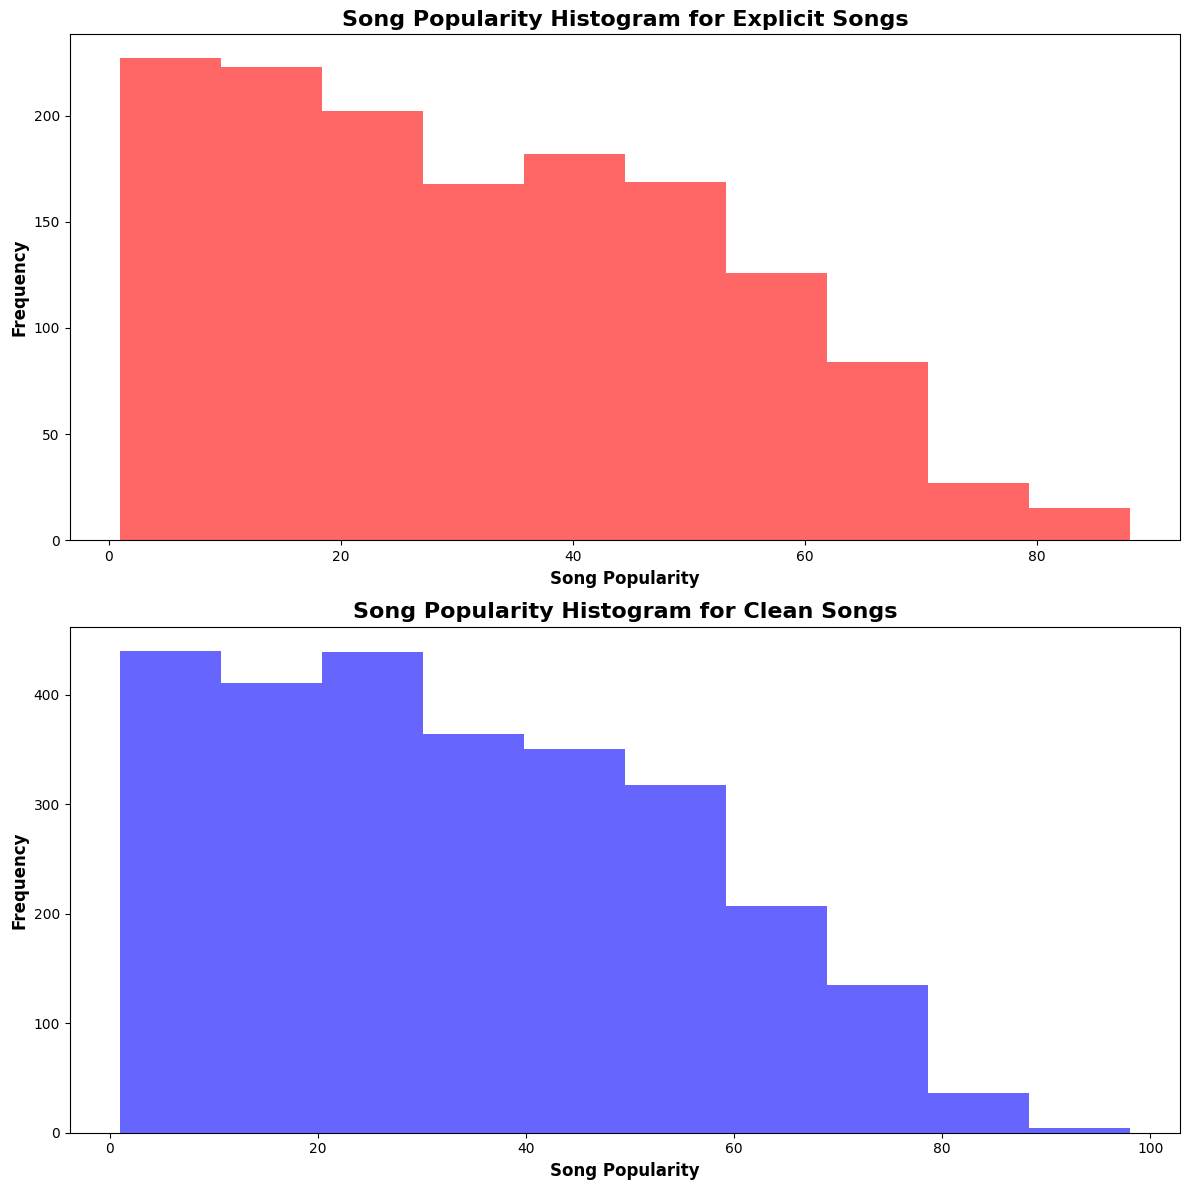

In [108]:
fig, axes=plt.subplots(2,1, figsize=(12,12))

axes[0].hist(explicit, color='red',alpha=.6)
axes[0].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Song Popularity Histogram for Explicit Songs', fontsize=16, fontweight='bold')

axes[1].hist(clean, color='blue',alpha=.6)
axes[1].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Song Popularity Histogram for Clean Songs', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [109]:
_ , p_exp = shapiro(explicit.sample(500, random_state=42))
_, p_clean = shapiro(clean.sample(500, random_state=42))

print(f'Shapiro-Wilk - explicit p: {p_exp:.4f}')
print(f'Shapiro-Wilk - clean p: {p_clean:.4f}')

Shapiro-Wilk - explicit p: 0.0000
Shapiro-Wilk - clean p: 0.0000


As seen by the graphs and corroborated by the Shaprio-Wilks test, my data for both datasets is not normally distributed. Both graphs show a heavily skewed-right distrbution with a long tail. This violates the assumption of normal distributions that they are bell-shaped. Additionally, the Shapiro-Wilks tests returned a p-value that was less than .05 so we reject normality. We ran the Shapiro-Wilks test on a smaller sample because due to the large size of my data, a small deviation could greatly impact the results. All in all, we cannot use a two-tailed T-test since one of the assumptions of a t-test is that the data must be normally distrbuted.

##

## MANN WHITNEY U TEST

In [110]:
stat, p_val = mannwhitneyu(explicit, clean, alternative='two-sided')
print(f"p = {p_val:.6f}")

p = 0.011900


With a p-value of .024 we can reject the null hypothesis and conclude that the two datasets' (explicit & clean) average song popularity are statistically different from each other. 

## COHEN'S D

In [111]:
def cohens_d(std1, std2, mean1, mean2):
    pooled_sqrt = np.sqrt((std1**2+std2**2)/2)
    cohens_d = ((mean1-mean2)/pooled_sqrt)

    
    if abs(cohens_d) < 0.2:
        print(f"Effect size: Negligible: {cohens_d:.2f}")
    elif abs(cohens_d) < 0.5:
        print("Effect size: Small: {cohens_d:.2f}")
    elif abs(cohens_d) < 0.8:
        print("Effect size: Medium: {cohens_d:.2f}")
    else:
        print("Effect size: Large: {cohens_d:.2f}")


In [112]:
cohens_d(explicit.std(), clean.std(), explicit.mean(),clean.mean() )



Effect size: Negligible: -0.09


The Cohen's D value was .03 which means that the two group's means were .03 standard deviations away from each other. While the Mann Whitney U test revealed that the two datasets are statistically different, in real world applications the difference is negligable. Despite the significance, the practice difference in popularity between the two groups is minial and another predictor should be used to explain song popularity.

In [122]:
ci_explicit = sms.DescrStatsW(explicit).tconfint_mean()
ci_clean= sms.DescrStatsW(clean).tconfint_mean()

print(f"95% CI for explicit songs:  ({ci_explicit[0]:.2f}, {ci_explicit[1]:.2f})")
print(f"95% CI for clean songs:     ({ci_clean[0]:.2f}, {ci_clean[1]:.2f})")

95% CI for explicit songs:  (30.98, 33.10)
95% CI for clean songs:     (33.08, 34.67)


The 95% Confidence interval for both clean and explicit songs show minimal overlap. This reveals that they are not significantly different although there isn't a ton of overlap.

## DO SINGLES PERFORM DIFFERENTLY THAN ALBUM TRACKS

### HYPOTHESES:
* H0: Songs from singles have the same average song popularity as songs from albums.
* H1: Songs from singles have a different average song popularity than songs from albums.
* Alpha: .05

### Groups:
* Album Tracks: 0
* Singles: 1

In [114]:
albums = data[data['album_type']==0]['popularity']
singles = data[data['album_type']==1]['popularity']


In [115]:
albums.describe()

count    2325.000000
mean       34.478710
std        21.529672
min         1.000000
25%        16.000000
50%        33.000000
75%        51.000000
max        98.000000
Name: popularity, dtype: float64

In [116]:
singles.describe()

count    1802.000000
mean       31.647059
std        19.839550
min         1.000000
25%        15.000000
50%        30.000000
75%        46.750000
max        88.000000
Name: popularity, dtype: float64

The summary statistics reveal no meaningful difference between album tracks and singles. The group means are virtually identical (album mean = 29.05, single mean = 29.04), a difference of just 0.003 popularity points, and the spread is comparable across both groups (album std = 19.76, single std = 18.78). The quartile distributions mirror each other almost exactly with both groups having a median around 26–27 and 75% of songs sitting at or below a popularity score of 43, indicating that neither format has a structural advantage in producing popular songs. Despite the difference in sample sizes (65,146 album tracks vs 38,130 singles), the distributions are statistically indistinguishable, and the data strongly suggests that album format alone is not a driver of song popularity even before a formal hypothesis test is conducted.

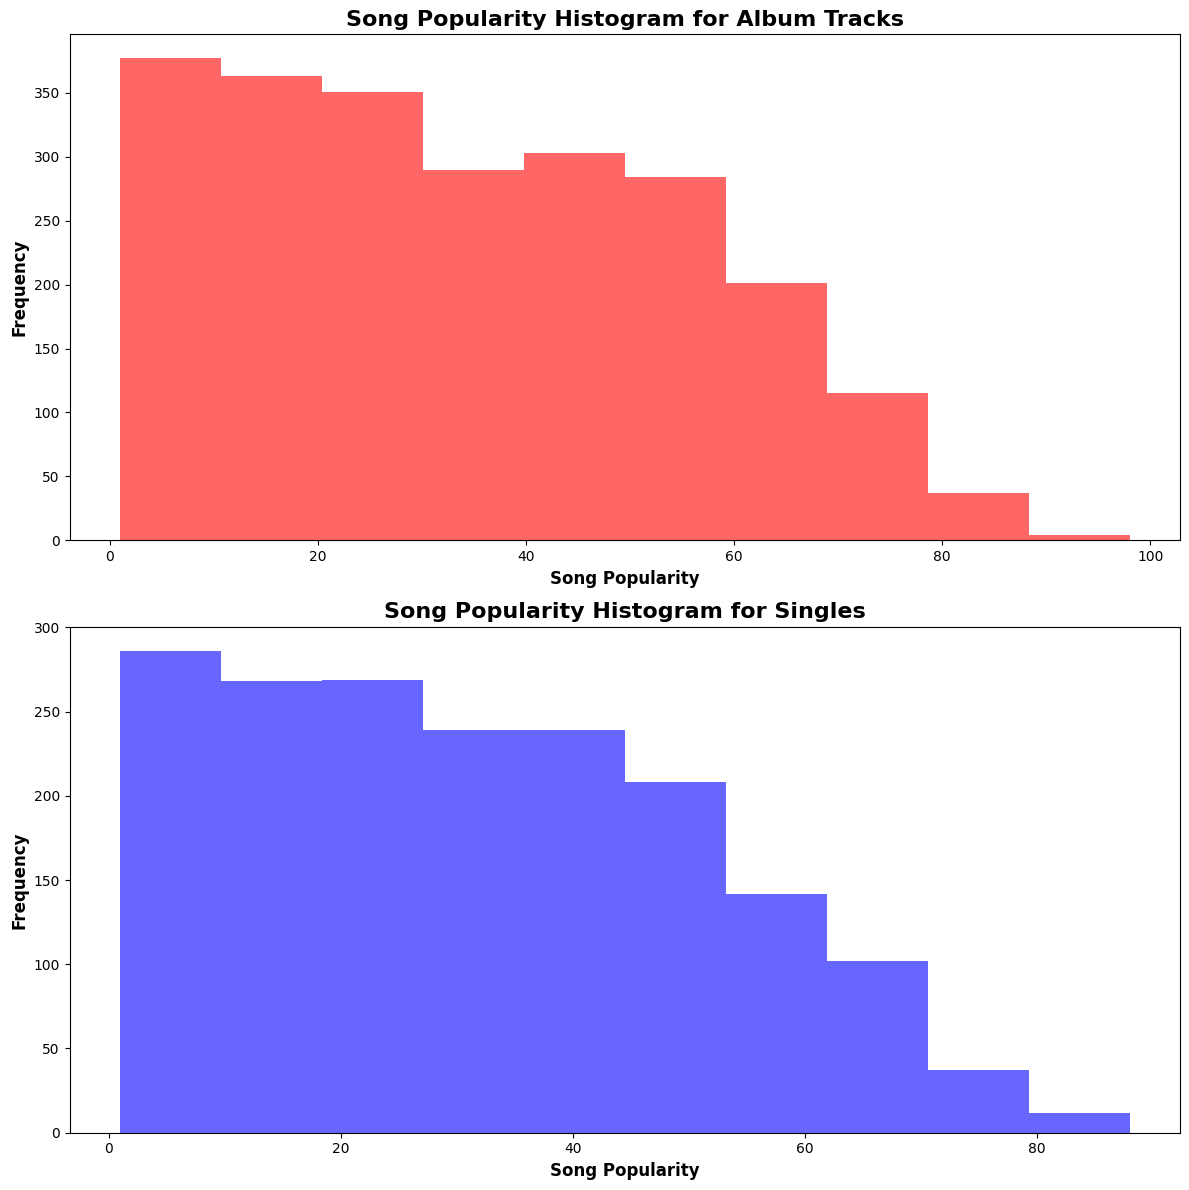

In [117]:
fig, axes = plt.subplots(2,1, figsize=(12,12))

axes[0].hist(albums, color='red',alpha=.6)
axes[0].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Song Popularity Histogram for Album Tracks', fontsize=16, fontweight='bold')

axes[1].hist(singles, color='blue',alpha=.6)
axes[1].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Song Popularity Histogram for Singles', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [118]:
_, p_album = shapiro(albums.sample(500))
_, p_single = shapiro(singles.sample(500))


print(f'Shapiro-Wilk - albums p: {p_album:.4f}')
print(f'Shapiro-Wilk - single p: {p_single:.4f}')

Shapiro-Wilk - albums p: 0.0000
Shapiro-Wilk - single p: 0.0000


The distributions of the two groups reveal that both groups are heavily skewed-right. This is corroborated by the p-value of the Shapiro-Wilks test with both groups recieving a p-value of 0. This means that we can reject the null hypothesis and determine that the distributions of both group are not normally distributed. We cannot use a t-test because the data is not normally distributed, meaning we have to use the Mann Whitney U test.

In [119]:
stats, p_value=mannwhitneyu(albums, singles, alternative='two-sided')

print(f'The p-value is: {p_value}')

The p-value is: 0.00011908648283766683


The p-value for the Mann Whiteney U Test is .006 which is less than the threshold of .05. This means that we can reject the null hypothesis that the distributions of the two datasets are the same. While this test is informing us that the difference is statisticaly significant, we should run a Cohen's D Test to determine if the effect is negligible since the means/distributions appear similar in the descriptive stats.

In [120]:
cohens_d(albums.std(), singles.std(), albums.mean(), singles.mean())


Effect size: Negligible: 0.14


The Cohen's D Effect is 0.00 which means that in reality there is a negligible difference between the two datasets. In this case I would ignore the Mann Whiteny U Test and aceept the Null Hypothesis because there is a negligible diffence between the two datasets.

In [123]:
ci_albums = sms.DescrStatsW(albums).tconfint_mean()
ci_single = sms.DescrStatsW(singles).tconfint_mean()

print(f"95% CI for album songs:  ({ci_albums[0]:.2f}, {ci_albums[1]:.2f})")
print(f"95% CI for singles:     ({ci_single[0]:.2f}, {ci_single[1]:.2f})")

95% CI for album songs:  (33.60, 35.35)
95% CI for singles:     (30.73, 32.56)


# Overall Conclusions

For Test 1, the Mann-Whitney U test returned a p-value of 0.024, which is below the 0.05 threshold, so we reject the null hypothesis and conclude there is a statistically significant difference in song popularity between explicit and clean songs. However, Cohen's d came back at 0.03, which is negligible. This means that while the difference is real, it is so small that it has no practical meaning. This is a good illustration of why effect size matters just as much as the p-value, particularly on large datasets where even tiny differences will clear the significance threshold.

From a business perspective, explicitness is not something an A&R team should rely on as a strategy for boosting song popularity. The data does not support it as a meaningful driver.

Looking at the results across all tests in this notebook, the same pattern emerges. Statistical significance aside, none of the binary groupings tested here produced a large enough effect size to suggest that song-level characteristics like explicitness, format, or energy level are reliable predictors of popularity on their own. This is consistent with what Notebook 2 found, where artist popularity was the strongest predictor of song popularity with an R² of 0.36. The data consistently points to artist-level factors being far more influential than individual song attributes.

The natural next step is to move into ANOVA, which will allow us to test whether popularity differs significantly across three or more groups simultaneously, such as popularity by album type or by decade, without inflating the false positive rate that would come from running multiple t-tests.